#1.Definicija problema:
   Analiza faktora koji utiču na indeks sreće (Happiness Score) u različitim zemljama sveta, sa ciljem predviđanja nivoa sreće na osnovu ekonomskih, socijalnih i političkih faktora.

# Ciljevi projekta
  Identifikacija ključnih faktora (npr. BDP po stanovniku, porodična podrška, očekivani životni vek) koji najviše doprinose sreći.

  Izgradnja modela mašinskog učenja za predviđanje Happiness Score na osnovu tih faktora.

# Očekivani rezultat:

  Model koji može tačno predvideti nivo sreće u zemljama na osnovu dostupnih indikatora.

# 2. Prikupljanje podataka

**Opis skupa podataka:**

-Dataset: 2015.csv (deo World Happiness Report).

-U delu country možemo primetiti spisak svih zemalja koje su uzete za ovo istraživanje i stavljene u dataset. Svaka zemlja se pojavljuje tačno 1 i imamo širok spektar zemalja iz svih regiona širom sveta, a tu su i zemlje Balkana gde se i mi nalazimo.

-Sadržaj: Podaci o indeksu sreće za 158 zemalja u 2015. godini, zajedno sa faktorima kao što su:

Ekonomski indikatori (BDP po stanovniku).

Socijalni faktori (porodična podrška, očekivani životni vek).

Politčki faktori (sloboda, korupcija).

Ostali (velikodušnost(zapravo odnosi se na vrednosti) , distopijski residual(ostatak koji govori o procentu 'nesrece' tj. koliko faktori utiču da su ljudi zapravo srećni, hipotetički govori o zemlji koja ima najgore faktore i koja je najmanje srećna) ).

**Struktura podataka:**

Country, Region: Kategorički podaci.

Happiness Score: Ciljna promenljiva (numerički podatak).


In [63]:
import numpy as np
import statsmodels.api as sm
import pandas as pd
from sklearn import linear_model
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as sm
from scipy import stats
from statsmodels.formula.api import ols


from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split # u trening delu delu podatke na obelezja i target
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import export_graphviz
import pydot
from datetime import datetime
import joblib
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

In [2]:
ins= pd.read_csv("2015.csv")
ins.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [3]:
ins.tail()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
153,Rwanda,Sub-Saharan Africa,154,3.465,0.03464,0.22208,0.77370,0.42864,0.59201,0.55191,0.22628,0.67042
154,Benin,Sub-Saharan Africa,155,3.340,0.03656,0.28665,0.35386,0.31910,0.48450,0.08010,0.18260,1.63328
155,Syria,Middle East and Northern Africa,156,3.006,0.05015,0.66320,0.47489,0.72193,0.15684,0.18906,0.47179,0.32858
156,Burundi,Sub-Saharan Africa,157,2.905,0.08658,0.01530,0.41587,0.22396,0.11850,0.10062,0.19727,1.83302
157,Togo,Sub-Saharan Africa,158,2.839,0.06727,0.20868,0.13995,0.28443,0.36453,0.10731,0.16681,1.56726


In [4]:
ins.columns

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Standard Error', 'Economy (GDP per Capita)', 'Family',
       'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)',
       'Generosity', 'Dystopia Residual'],
      dtype='object')

In [5]:
br_redova= len(ins)

br_redova

158

In [6]:
ins.shape

(158, 12)

# 3. Vizuelizacija podataka i bazična statistička analiza

In [7]:
ins.describe()

,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,79.493671,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,45.754363,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,40.250000,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,79.500000,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,118.750000,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,158.000000,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


In [8]:
ins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 1

<Figure size 1000x800 with 0 Axes>

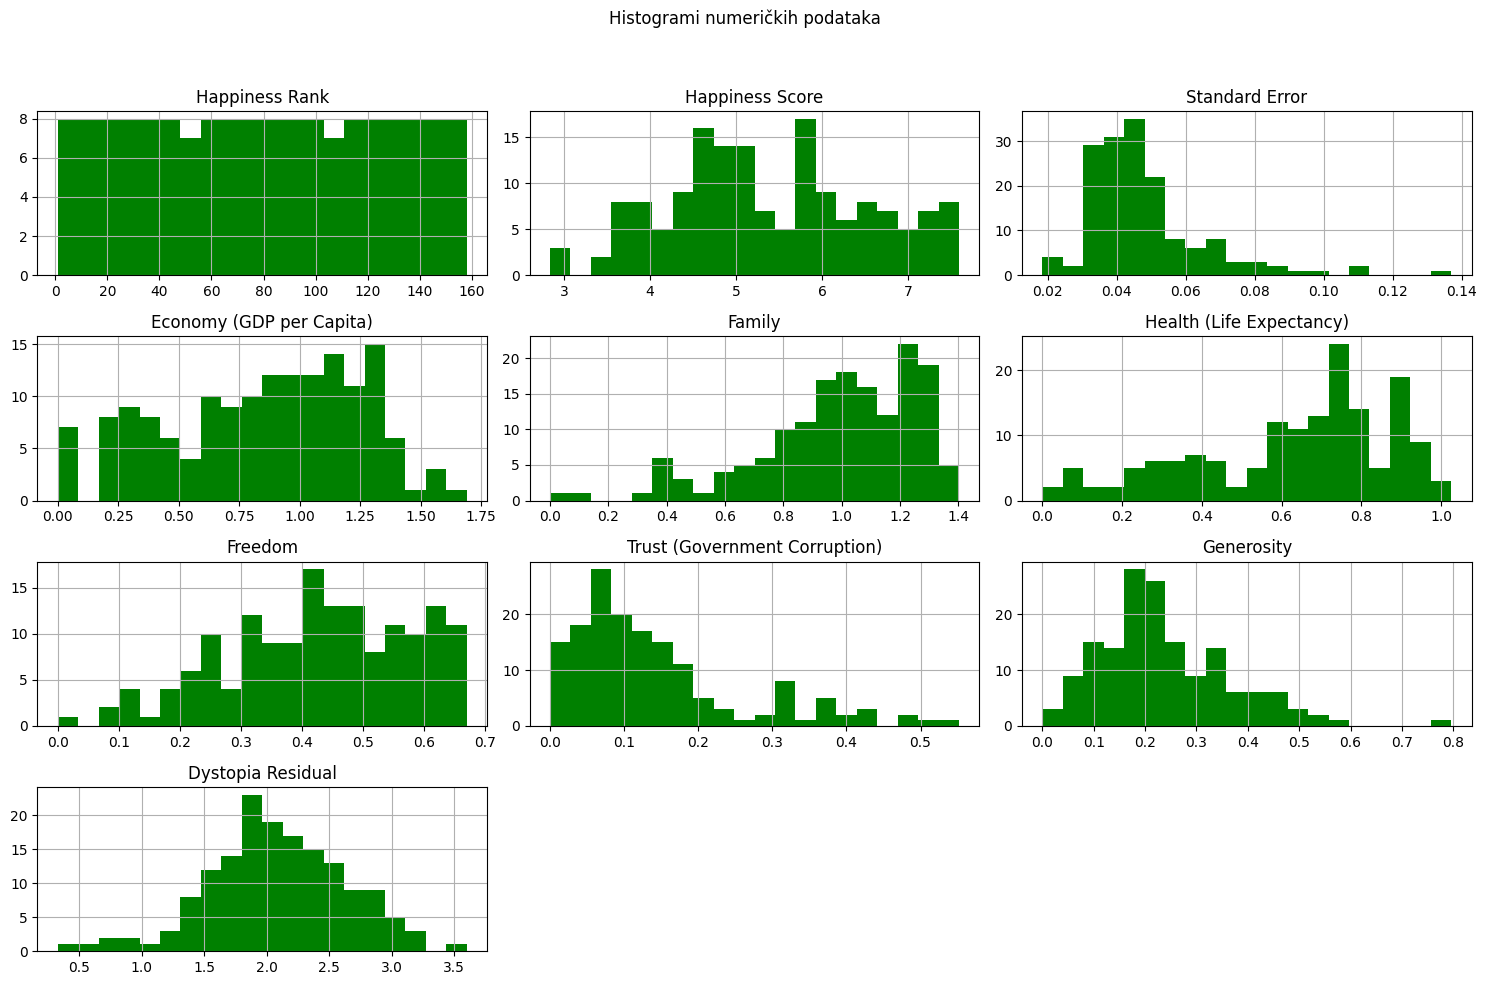

In [9]:
plt.figure(figsize = (10, 8))
ins.hist(bins = 20, figsize = (15, 10), color ='green')
plt.suptitle('Histogrami numeričkih podataka')
plt.tight_layout(rect = [0, 0, 1, 0.95])
plt.show()

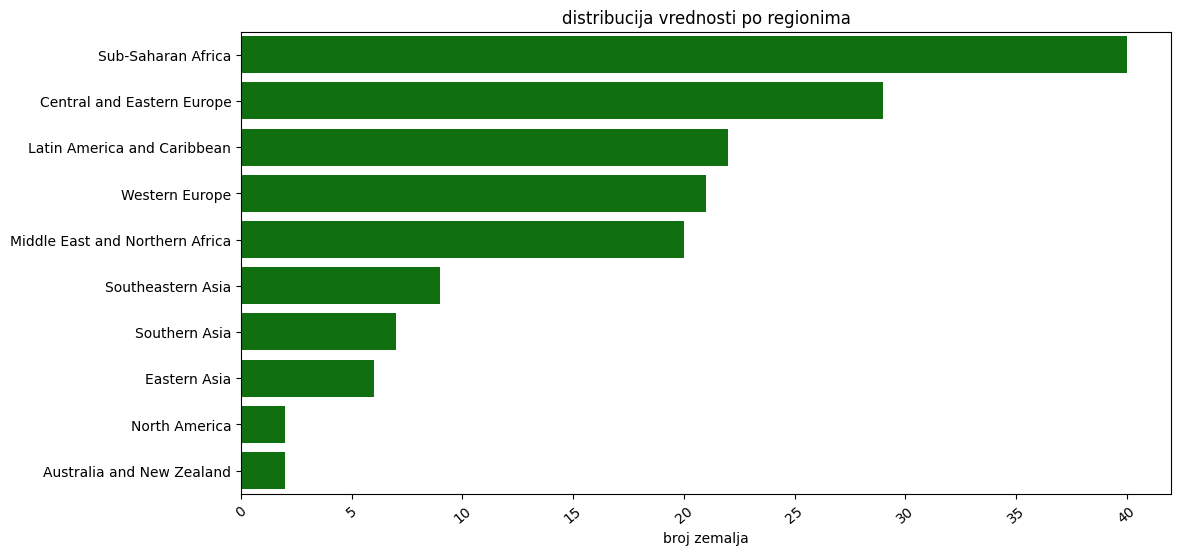

In [10]:
if 'Region' in ins.columns:
  plt.figure(figsize = (12,6))
  sns.countplot (data = ins, y= 'Region', order = ins['Region'].value_counts().index, color='green')
  plt.title('distribucija vrednosti po regionima')
  plt.xlabel('broj zemalja')
  plt.ylabel('')
  plt.xticks(rotation = 40)
  plt.show()

<Axes: xlabel='Region', ylabel='Family'>

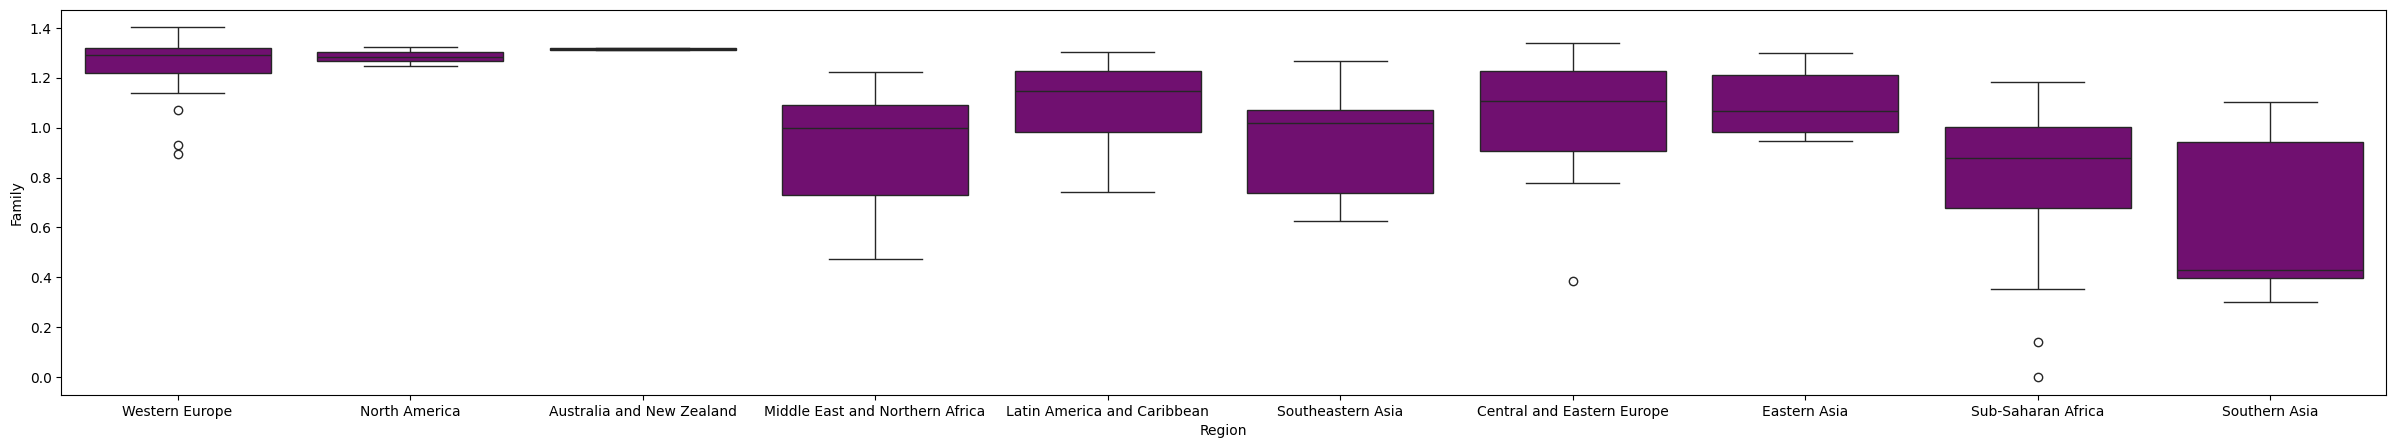

In [11]:
#box koji pokazuje uticaj porodice na srecu po regionu

plt.figure(figsize = (30,5))
sns.boxplot(data= ins, x='Region', y = 'Family', color='purple' )

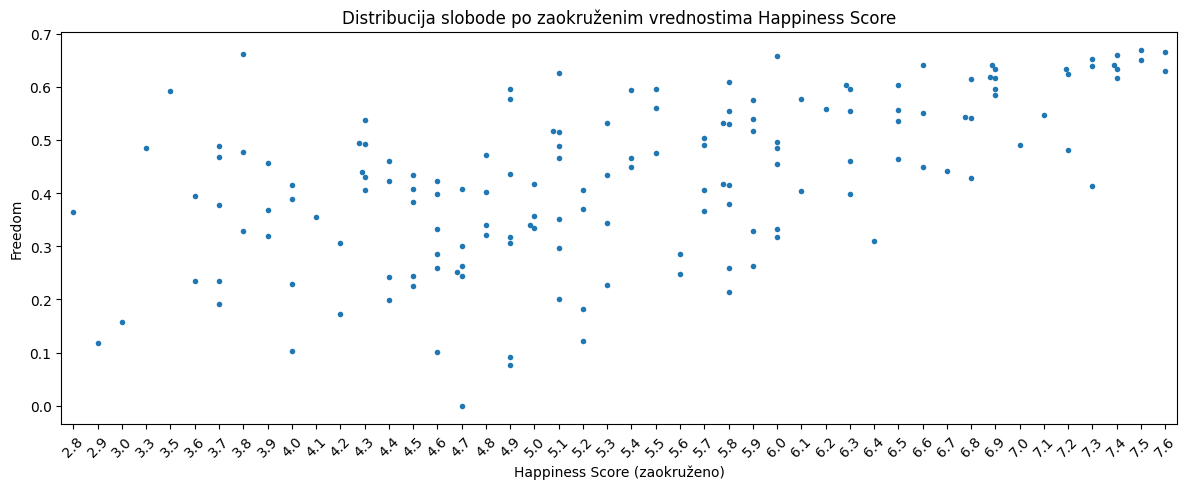

In [12]:
dff_sorted = ins.copy()
dff_sorted["Happiness Score Rounded"] = dff_sorted["Happiness Score"].round(1)

plt.figure(figsize=(12, 5))
sns.swarmplot(data=dff_sorted, x='Happiness Score Rounded', y='Freedom', size=4)
plt.title('Distribucija slobode po zaokruženim vrednostima Happiness Score')
plt.xlabel('Happiness Score (zaokruženo)')
plt.ylabel('Freedom')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1524/849138675.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ins, x="Happiness Score", y="Country", palette="viridis")


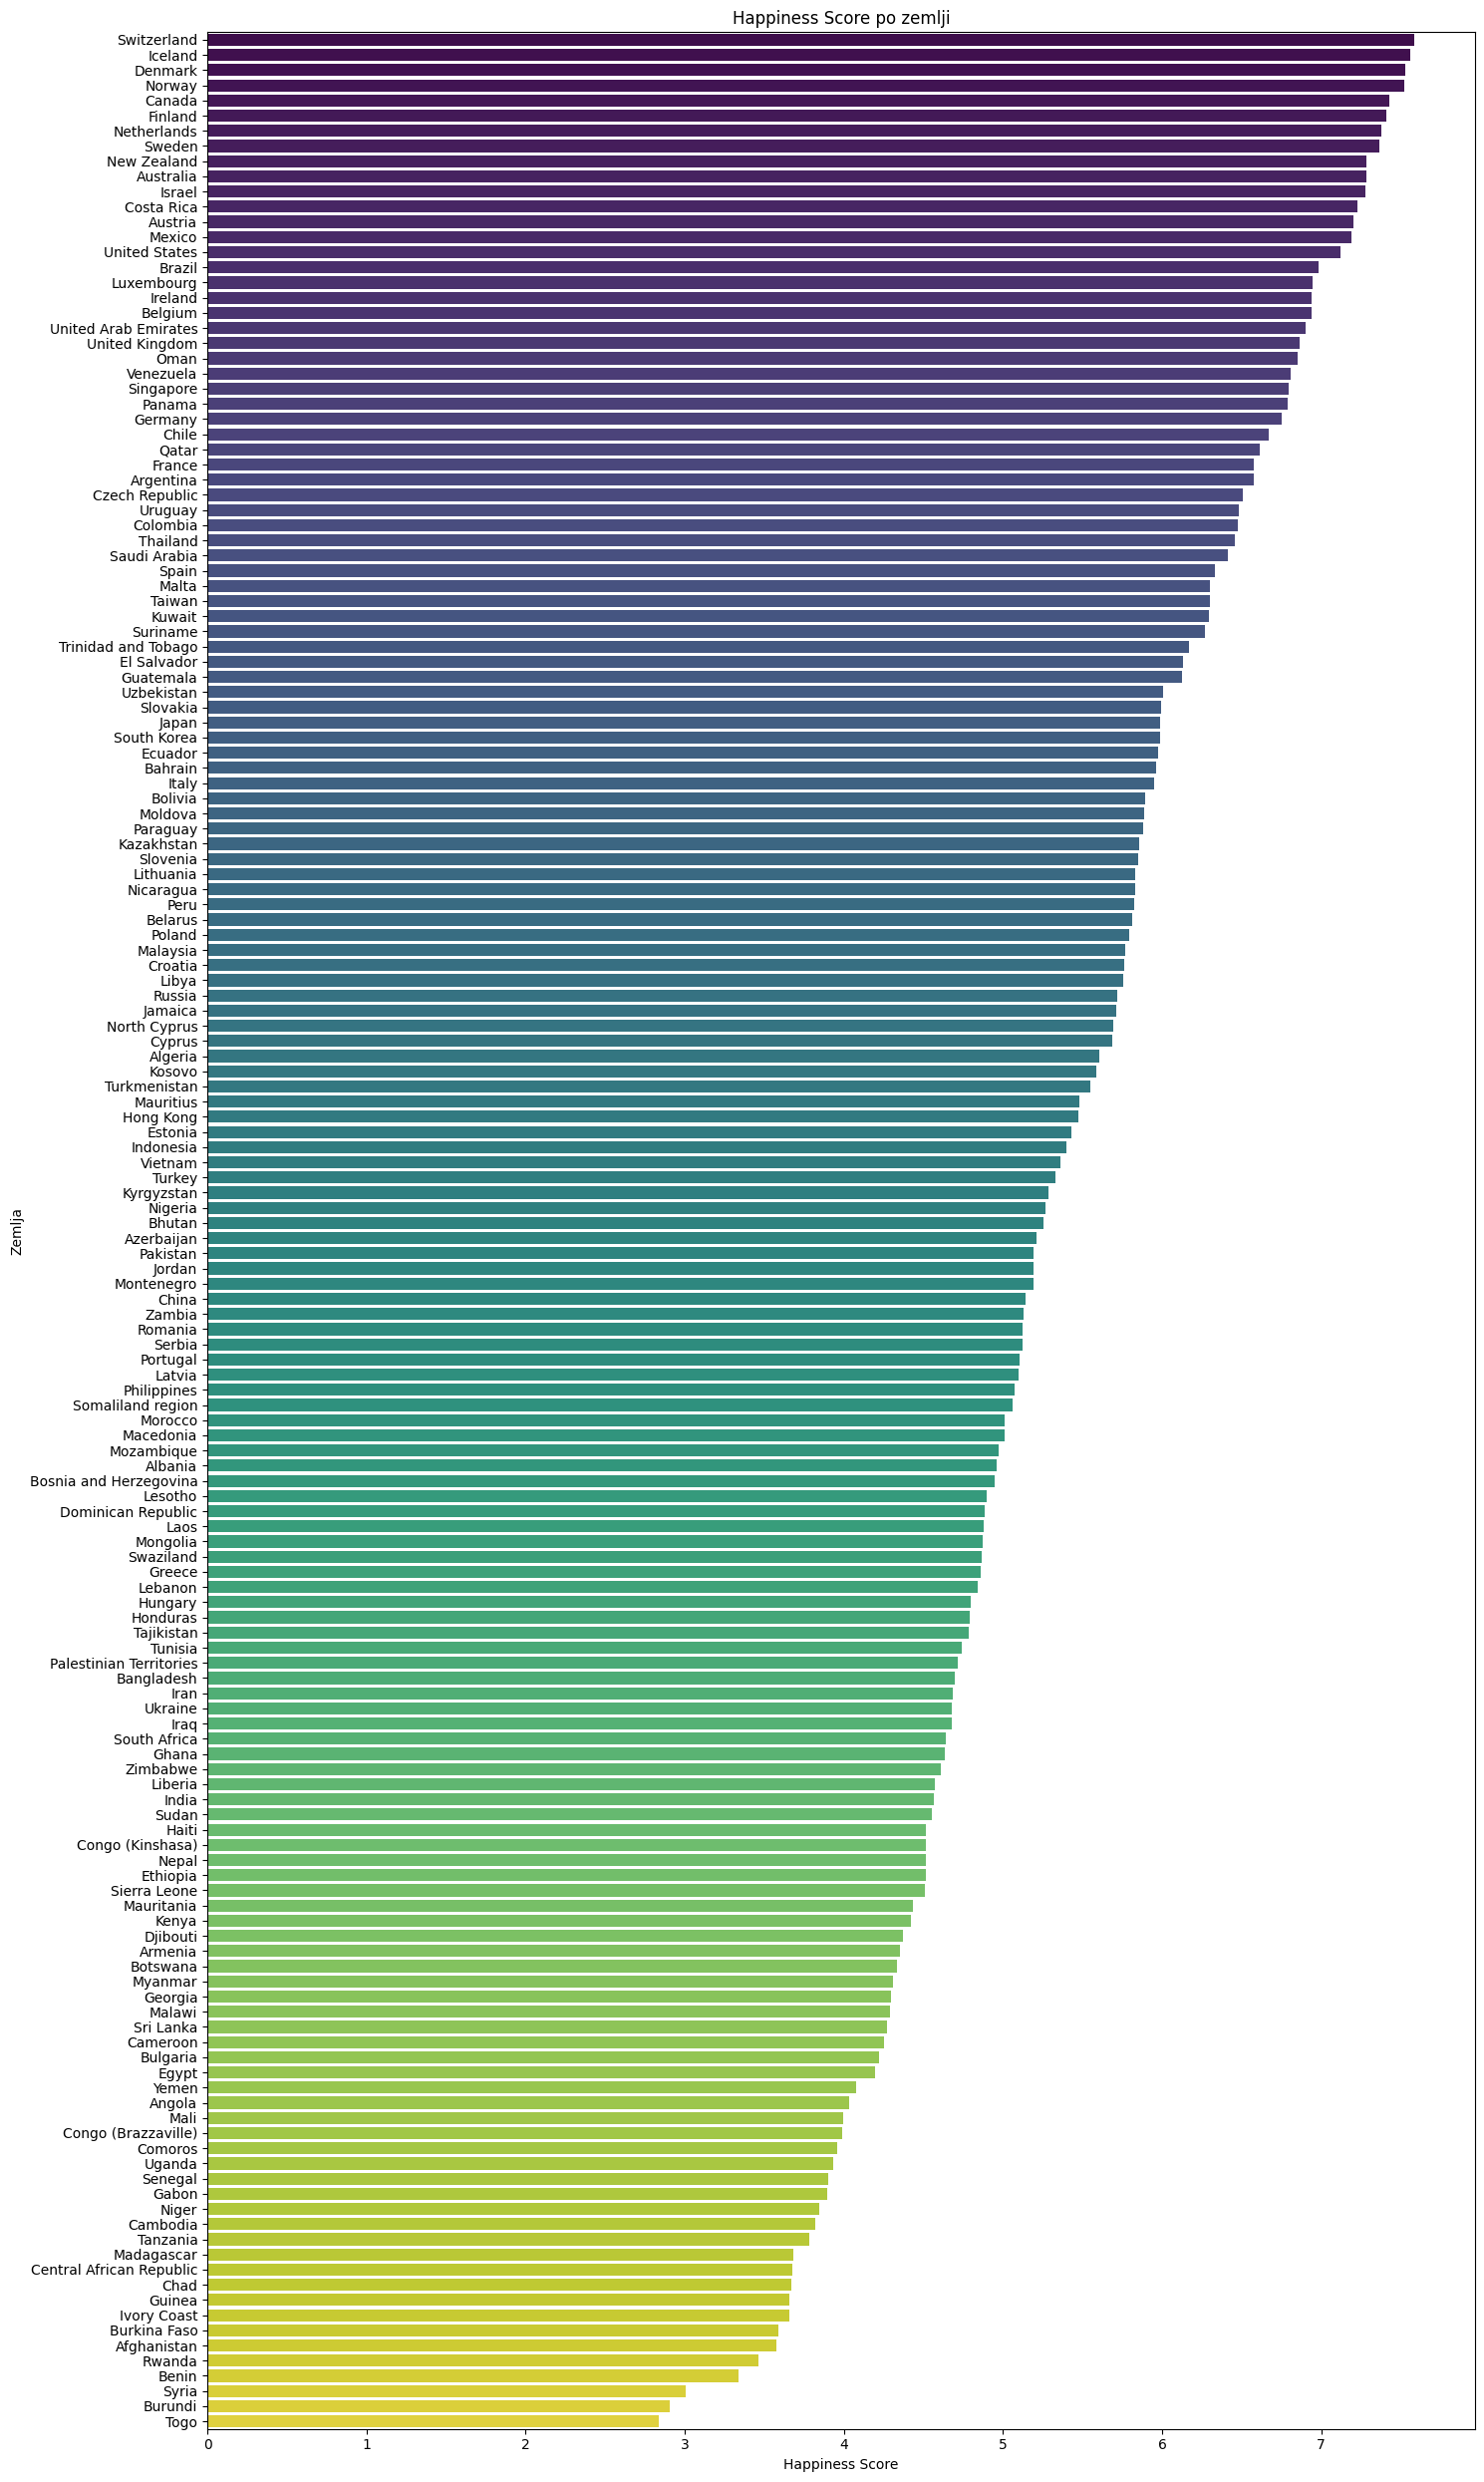

In [13]:
plt.figure(figsize=(15, 25))
sns.barplot(data=ins, x="Happiness Score", y="Country", palette="viridis")

plt.title("Happiness Score po zemlji")
plt.xlabel("Happiness Score")
plt.ylabel("Zemlja")
plt.tight_layout()
plt.show()


In [14]:
numeric_df = ins.select_dtypes(include = [np.number])
corr_matrix = numeric_df.corr()

print(corr_matrix)

                               Happiness Rank  Happiness Score  \
Happiness Rank                       1.000000        -0.992105   
Happiness Score                     -0.992105         1.000000   
Standard Error                       0.158516        -0.177254   
Economy (GDP per Capita)            -0.785267         0.780966   
Family                              -0.733644         0.740605   
Health (Life Expectancy)            -0.735613         0.724200   
Freedom                             -0.556886         0.568211   
Trust (Government Corruption)       -0.372315         0.395199   
Generosity                          -0.160142         0.180319   
Dystopia Residual                   -0.521999         0.530474   

                               Standard Error  Economy (GDP per Capita)  \
Happiness Rank                       0.158516                 -0.785267   
Happiness Score                     -0.177254                  0.780966   
Standard Error                       1.000000   

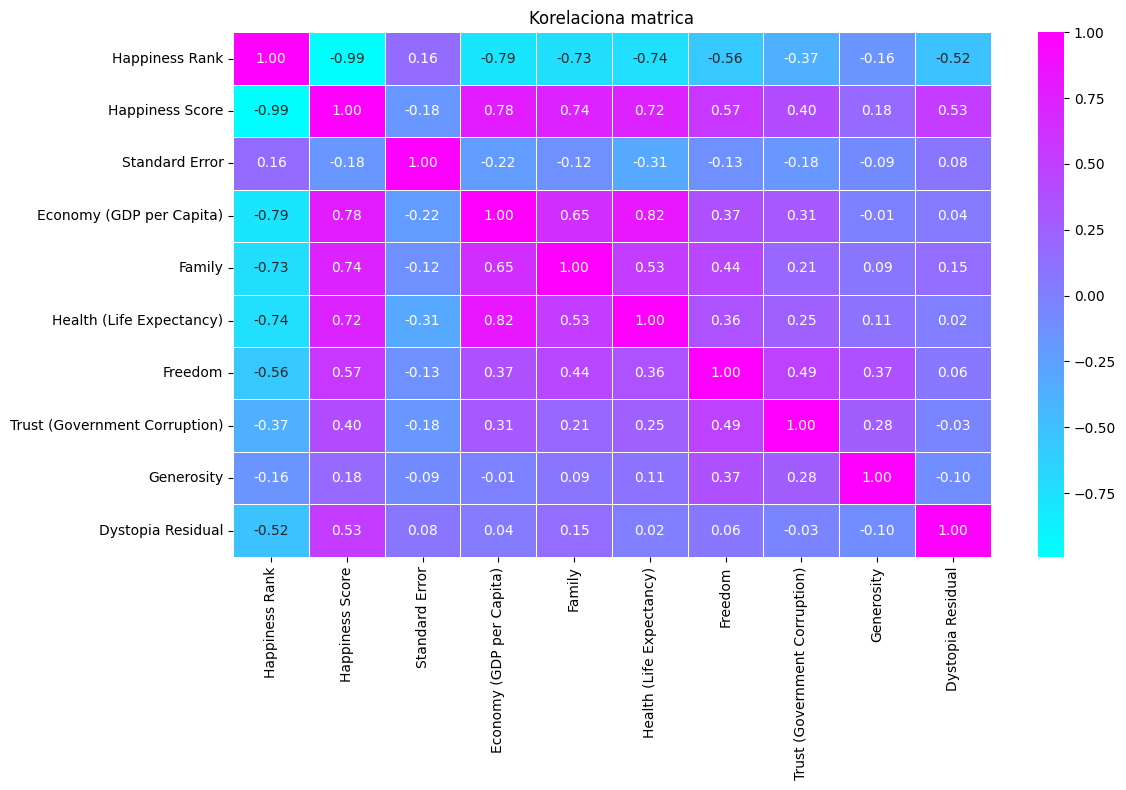

In [15]:
plt.figure(figsize = (12, 8))
sns.heatmap(corr_matrix, annot = True, fmt = '.2f', cmap = 'cool', linewidth = 0.5)
plt.title("Korelaciona matrica")
plt.tight_layout()

# 4. Predobrada podataka:

In [16]:
ins.dtypes

,0
Country,object
Region,object
Happiness Rank,int64
Happiness Score,float64
Standard Error,float64
Economy (GDP per Capita),float64
Family,float64
Health (Life Expectancy),float64
Freedom,float64
Trust (Government Corruption),float64


In [17]:
# Frequency Encoding za 'Region'
# Broj pojavljivanja svake regije (apsolutna frekvencija)
region_counts = ins['Region'].value_counts(normalize=True).to_dict()
ins['Region_Freq_Encoded'] = ins['Region'].map(region_counts)


In [18]:
print("Dostupne kolone:", ins.columns.tolist())

Dostupne kolone: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual', 'Region_Freq_Encoded']


In [19]:
ins['Region'].unique()

array(['Western Europe', 'North America', 'Australia and New Zealand',
       'Middle East and Northern Africa', 'Latin America and Caribbean',
       'Southeastern Asia', 'Central and Eastern Europe', 'Eastern Asia',
       'Sub-Saharan Africa', 'Southern Asia'], dtype=object)

In [20]:
ins['Region_Freq_Encoded'].unique()

array([0.13291139, 0.01265823, 0.12658228, 0.13924051, 0.05696203,
       0.1835443 , 0.03797468, 0.25316456, 0.0443038 ])

In [21]:
print(ins['Region'].value_counts(normalize=True))

Region
Sub-Saharan Africa                 0.253165
Central and Eastern Europe         0.183544
Latin America and Caribbean        0.139241
Western Europe                     0.132911
Middle East and Northern Africa    0.126582
Southeastern Asia                  0.056962
Southern Asia                      0.044304
Eastern Asia                       0.037975
North America                      0.012658
Australia and New Zealand          0.012658
Name: proportion, dtype: float64


In [22]:
print(ins[['Region', 'Region_Freq_Encoded']].drop_duplicates().sort_values(by='Region'))

                             Region  Region_Freq_Encoded
8         Australia and New Zealand             0.012658
30       Central and Eastern Europe             0.183544
37                     Eastern Asia             0.037975
11      Latin America and Caribbean             0.139241
10  Middle East and Northern Africa             0.126582
4                     North America             0.012658
23                Southeastern Asia             0.056962
78                    Southern Asia             0.044304
70               Sub-Saharan Africa             0.253165
0                    Western Europe             0.132911


In [23]:
#prosečni Happiness Score po zemlji
country_target = ins.groupby('Country')['Happiness Score'].mean().to_dict()

In [24]:
ins['Country_Target_Encoded'] = ins['Country'].map(country_target)

In [25]:
ins.drop('Country', axis=1, inplace=True)

In [26]:
ins.drop('Region', axis=1, inplace=True)

In [27]:
final_data = ins[['Country_Target_Encoded','Region_Freq_Encoded', 'Happiness Score','Standard Error','Economy (GDP per Capita)','Family'	,'Health (Life Expectancy)',	'Freedom',	'Trust (Government Corruption)',	'Generosity',	'Dystopia Residual'  ]]

In [28]:
final_data.to_csv('happiness_data_encoded.csv', index=False)

In [29]:
ins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Happiness Rank                 158 non-null    int64  
 1   Happiness Score                158 non-null    float64
 2   Standard Error                 158 non-null    float64
 3   Economy (GDP per Capita)       158 non-null    float64
 4   Family                         158 non-null    float64
 5   Health (Life Expectancy)       158 non-null    float64
 6   Freedom                        158 non-null    float64
 7   Trust (Government Corruption)  158 non-null    float64
 8   Generosity                     158 non-null    float64
 9   Dystopia Residual              158 non-null    float64
 10  Region_Freq_Encoded            158 non-null    float64
 11  Country_Target_Encoded         158 non-null    float64
dtypes: float64(11), int64(1)
memory usage: 14.9 KB


# 5 i 6. Treniranje i evaluacija modela: (izabran RandomForest)

In [32]:
X = final_data[: :-1]
y = final_data[: -1]
features = ins.drop('Happiness Score', axis = 1)

X, y
features_list=list(features.columns)

In [33]:
labels = np.array(ins['Happiness Score'])
features_list=list(features.columns)

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size = 0.2, random_state = 42)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(126, 11)
(126,)
(32, 11)
(32,)


In [34]:
#prosečna vrednost Happiness Score iz trening skupa, hocu hocu sada vidim da nisam...
baseline_value = np.mean(y_train)

#predviđanja osnovice (isti prosek za sve test primere)
baseline_predictions = np.full_like(y_test, baseline_value)

# apsolutne greške
errors = abs(baseline_predictions - y_test)


In [35]:
baseline_value

np.float64(5.392992063492064)

In [36]:
baseline_predictions

array([5.39299206, 5.39299206, 5.39299206, 5.39299206, 5.39299206,
       5.39299206, 5.39299206, 5.39299206, 5.39299206, 5.39299206,
       5.39299206, 5.39299206, 5.39299206, 5.39299206, 5.39299206,
       5.39299206, 5.39299206, 5.39299206, 5.39299206, 5.39299206,
       5.39299206, 5.39299206, 5.39299206, 5.39299206, 5.39299206,
       5.39299206, 5.39299206, 5.39299206, 5.39299206, 5.39299206,
       5.39299206, 5.39299206])

In [37]:
errors

array([1.08599206, 0.59400794, 1.19899206, 2.48799206, 0.33599206,
       1.18100794, 0.49499206, 0.51699206, 0.44399206, 1.46199206,
       1.50800794, 0.43500794, 1.59000794, 0.15500794, 1.39300794,
       1.11200794, 0.88599206, 0.70699206, 0.42199206, 0.30200794,
       1.73799206, 1.54400794, 1.80700794, 1.89100794, 1.09200794,
       0.20099206, 0.49600794, 1.43699206, 1.02399206, 1.71199206,
       1.61199206, 0.06099206])

In [38]:
rf = RandomForestRegressor(n_estimators = 1000, random_state = 42)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=1000, random_state=42)

In [39]:
predictions = rf.predict(X_test)
errors = abs(predictions - y_test)
print("Mean absolute error: ", round(np.mean(errors), 2))

Mean absolute error:  0.02


In [40]:
mape = 100 * (errors / y_test)
accuracy = 100 - np.mean(mape)
print("Accuracy: ", round(accuracy, 2), '%')

Accuracy:  99.43 %


In [41]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

y_pred = rf.predict(X_test)
print("R² score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:",mean_absolute_error(y_test, y_pred))
print("RMSE:",root_mean_squared_error(y_test, y_pred))

R² score: 0.9986821303515647
MSE: 0.0018697284478742496
MAE: 0.024321437499990273
RMSE: 0.043240356703827615


In [42]:
y_pred = rf.predict(X_test)
y_pred

array([4.299463, 5.978525, 4.215352, 3.112452, 5.086772, 6.609665,
       4.876228, 4.86243 , 4.957921, 3.909519, 6.876358, 5.834814,
       6.997131, 5.570164, 6.798505, 6.51152 , 4.510449, 4.685623,
       4.992578, 5.695477, 3.634801, 6.910296, 7.264369, 7.307261,
       6.45483 , 5.194081, 5.879458, 3.972956, 4.376333, 3.647828,
       3.831499, 5.337346])

In [43]:
tree = rf.estimators_[7]
tree

DecisionTreeRegressor(max_features=1.0, random_state=415968276)

In [44]:
export_graphviz(tree, out_file = 'tree.dot', feature_names = features_list, rounded = True, precision = 1)

(graph, ) = pydot.graph_from_dot_file('tree.dot')

graph.write_png('tree.png')

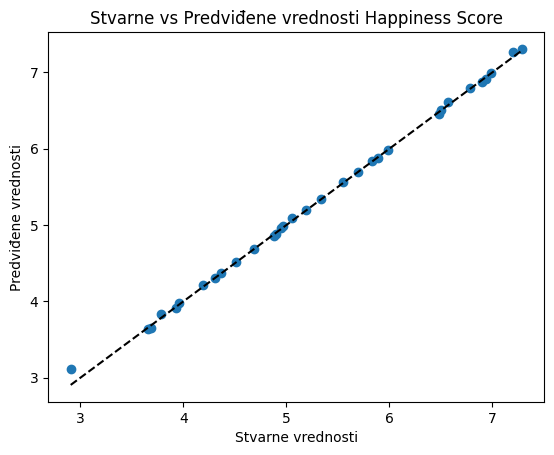

In [45]:
plt.scatter(y_test, y_pred)
plt.xlabel('Stvarne vrednosti')
plt.ylabel('Predviđene vrednosti')
plt.title('Stvarne vs Predviđene vrednosti Happiness Score')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'k--')
plt.show()

In [46]:
# Primer predviđanja za novu zemlju
nova_zemlja = [[1.2, 1.5, 0.8, 0.7, 0.3, 0.5, 2.5,3.6,1.6,2.7,1.09]]  # Redosled: GDP, Family, Health, Freedom, Corruption, Generosity, Dystopia
predvidjeni_score = rf.predict(nova_zemlja)
print("Predviđeni Happiness Score:", predvidjeni_score[0])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Predviđeni Happiness Score: 5.4987319999999915


In [47]:
from xgboost import XGBRegressor

In [48]:
xgb = XGBRegressor()
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [49]:
y_predx = xgb.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_predx))
print("MAE:",mean_absolute_error(y_test, y_predx))
print("R² score:", r2_score(y_test, y_predx))
print("RMSE:",root_mean_squared_error(y_test, y_predx))

MSE: 0.0045326347097375715
MAE: 0.047365967631340045
R² score: 0.9968051929047778
RMSE: 0.06732484466924206


In [50]:
y_predx = xgb.predict(X_test)
# apsolutne greške
errors = abs(y_predx  - y_test)

In [51]:
mape = 100 * (errors / y_test)
accuracy = 100 - np.mean(mape)
print("Accuracy: ", round(accuracy, 2), '%')

Accuracy:  99.08 %


In [52]:
from sklearn.linear_model import LinearRegression

In [53]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [54]:
y_pred_lr = lr.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("MAE:",mean_absolute_error(y_test, y_pred_lr))
print("R² score:", r2_score(y_test, y_pred_lr))
print("RMSE:",root_mean_squared_error(y_test, y_pred_lr))

MSE: 1.8355190890779215e-28
MAE: 1.1921019726912618e-14
R² score: 1.0
RMSE: 1.3548133041411726e-14


In [55]:
y_pred_lr = lr.predict(X_test)
# apsolutne greške
errors = abs(y_pred_lr - y_test)

In [56]:
mape = 100 * (errors / y_test)
accuracy = 100 - np.mean(mape)
print("Accuracy: ", round(accuracy, 2), '%')

Accuracy:  100.0 %


In [57]:
y_pred = rf.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:",mean_absolute_error(y_test, y_pred))
print("R² score:", r2_score(y_test, y_pred))
print("RMSE:",root_mean_squared_error(y_test, y_pred))

MSE: 0.0018697284478742496
MAE: 0.024321437499990273
R² score: 0.9986821303515647
RMSE: 0.043240356703827615


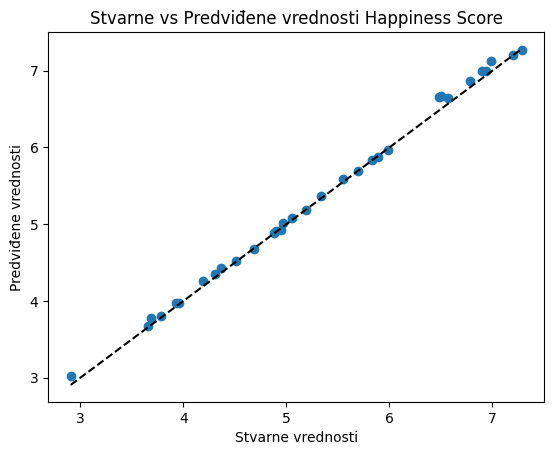

In [58]:
#dijagram XGBRegressor
plt.scatter(y_test, y_predx)
plt.xlabel('Stvarne vrednosti')
plt.ylabel('Predviđene vrednosti')
plt.title('Stvarne vs Predviđene vrednosti Happiness Score')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'k--')
plt.show()

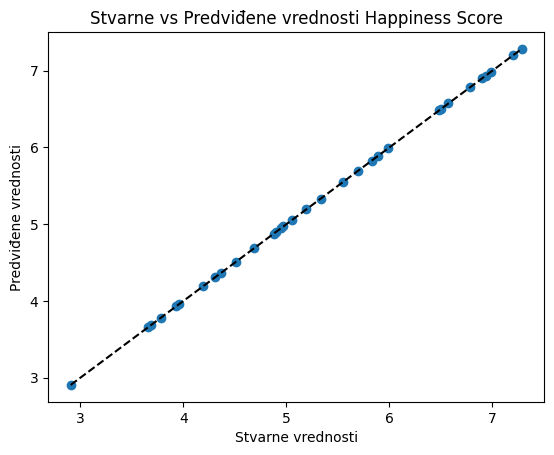

In [59]:
#dijagram Linearne regresije
plt.scatter(y_test, y_pred_lr)
plt.xlabel('Stvarne vrednosti')
plt.ylabel('Predviđene vrednosti')
plt.title('Stvarne vs Predviđene vrednosti Happiness Score')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'k--')
plt.show()

In [60]:
# Primer predviđanja za novu zemlju
nova_zemlja = [[1.2, 1.5, 0.8, 0.7, 0.3, 0.5, 2.5,3.6,1.6,2.7,1.09]]  # Redosled: GDP, Family, Health, Freedom, Corruption, Generosity, Dystopia
predvidjeni_score = xgb.predict(nova_zemlja)
print("Predviđeni Happiness Score:", predvidjeni_score[0])

Predviđeni Happiness Score: 7.5849075


In [61]:
# Primer predviđanja za novu zemlju
nova_zemlja = [[1.2, 1.5, 0.8, 0.7, 0.3, 0.5, 2.5,3.6,1.6,2.7,1.09]]  # Redosled: GDP, Family, Health, Freedom, Corruption, Generosity, Dystopia
predvidjeni_score = lr.predict(nova_zemlja)
print("Predviđeni Happiness Score:", predvidjeni_score[0])

Predviđeni Happiness Score: 1.09000000000091


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


primer MLP reggresior-a

In [64]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [65]:
mlp = MLPRegressor(
    hidden_layer_sizes=(32, 16),   # 2 skrivena sloja: 32 pa 16 neurona
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)
mlp.fit(X_train_scaled, y_train)

MLPRegressor(hidden_layer_sizes=(32, 16), max_iter=2000, random_state=42)

In [66]:
y_pred_mlp = mlp.predict(X_test_scaled)


In [67]:
print("MSE:", mean_squared_error(y_test, y_pred_mlp))
print("MAE:", mean_absolute_error(y_test, y_pred_mlp))
print("R² score:", r2_score(y_test, y_pred_mlp))
print("RMSE:", root_mean_squared_error(y_test, y_pred_mlp))

MSE: 0.3922914015385189
MAE: 0.5220539383214522
R² score: 0.7234951781273191
RMSE: 0.626331702485607


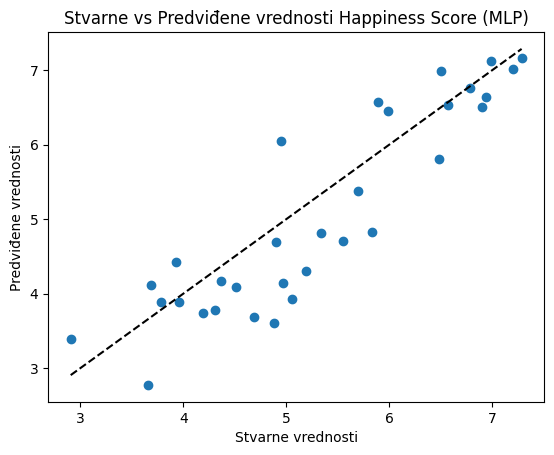

In [68]:
plt.scatter(y_test, y_pred_mlp)
plt.xlabel('Stvarne vrednosti')
plt.ylabel('Predviđene vrednosti')
plt.title('Stvarne vs Predviđene vrednosti Happiness Score (MLP)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.show()

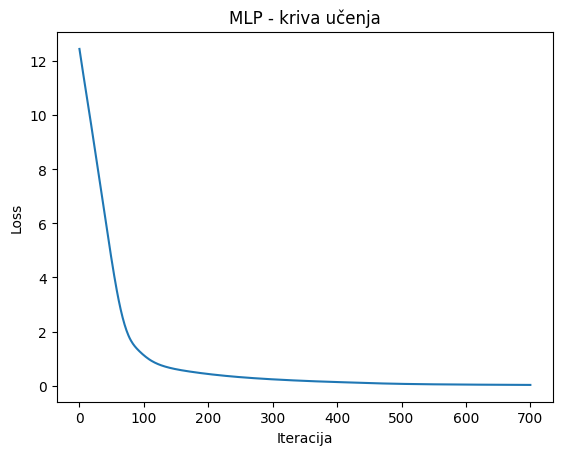

In [69]:
plt.plot(mlp.loss_curve_)
plt.xlabel("Iteracija")
plt.ylabel("Loss")
plt.title("MLP - kriva učenja")
plt.show()